### 군집화 (K-means, 비지도학습)

목표: 이탈 여부(Target)를 사용하지 않고, 고객의 행동·이용 패턴만으로 비슷한 고객끼리 그룹을 나누기  
나눈 뒤에 각 그룹의 실제 이탈률을 비교해서, 어떤 유형의 고객이 위험한지 확인


행동 변수만으로 자연스럽게 형성되는 고객 유형을 찾고, 그 유형이 이탈과 관련 있는지는 나중에 검증용으로 확인

### 라이브러리 & 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

### 군집용 변수 선정

Target(이탈 여부)은 사용하지 않고, 분류 모델의 feature importance 상위 변수 + 행동 변수 위주로 선정.

- Total_Trans_Amt: 거래금액 (활동성)   
Total_Trans_Ct(거래건수)와 상관계수 0.81로 거의 같은 정보라 하나만 사용.
- Total_Amt_Chng_Q4_Q1: 4분기 대비 1분기 거래금액 변화율 (최근 사용 트렌드)
- Avg_Utilization_Ratio: 한도소진율
- Total_Revolving_Bal: 리볼빙 잔액
- Contacts_Count_12_mon: 고객센터 문의 횟수
- Total_Relationship_Count: 보유 상품 개수
- Customer_Age: 나이. 행동 변수는 아니지만 분류 모델에서 중요도가 높아 세대별 차이도 반영하기 위해 포함.

In [2]:
cluster_cols = [
    "Total_Trans_Amt", "Total_Amt_Chng_Q4_Q1", "Avg_Utilization_Ratio",
    "Total_Revolving_Bal", "Contacts_Count_12_mon", "Total_Relationship_Count",
    "Customer_Age",
]

X_cluster = df[cluster_cols].copy()
X_cluster.describe()

,Total_Trans_Amt,Total_Amt_Chng_Q4_Q1,Avg_Utilization_Ratio,Total_Revolving_Bal,Contacts_Count_12_mon,Total_Relationship_Count,Customer_Age
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,4404.086304,0.759941,0.274894,1162.814061,2.455317,3.812580,46.325960
std,3397.129254,0.219207,0.275691,814.987335,1.106225,1.554408,8.016814
min,510.000000,0.000000,0.000000,0.000000,0.000000,1.000000,26.000000
25%,2155.500000,0.631000,0.023000,359.000000,2.000000,3.000000,41.000000
50%,3899.000000,0.736000,0.176000,1276.000000,2.000000,4.000000,46.000000
75%,4741.000000,0.859000,0.503000,1784.000000,3.000000,5.000000,52.000000
max,18484.000000,3.397000,0.999000,2517.000000,6.000000,6.000000,73.000000


### 스케일링

 StandardScaler로 각 변수를 평균 0, 표준편차 1로 맞춘 뒤 군집화를 진행

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]

array([[-0.95970657,  2.62349444, -0.77588223, -0.47342222,  0.49240377,
         0.76394261, -0.16540558],
       [-0.91643261,  3.56329284, -0.61627565, -0.36666682, -0.41161598,
         1.40730617,  0.33357038],
       [-0.74098169,  8.36721381, -0.99715499, -1.42685834, -2.21965548,
         0.12057905,  0.58305837],
       [-0.95175829,  2.94284341,  1.75968594,  1.6616857 , -1.31563573,
        -0.52278451, -0.78912553],
       [-1.05626345,  6.4556821 , -0.99715499, -1.42685834, -2.21965548,
         0.76394261, -0.78912553]])

### 최적 군집 수 탐색 (Elbow Method + 실루엣 점수)

군집 수(k)를 2~8까지 바꿔가며 inertia(군집 내 거리 제곱합)와 실루엣 스코어를 함께 확인  
Elbow만으로는 적정 k가 애매하게 나오는 경우가 많아, 실루엣 점수를 함께 비교해서 최종 k를 결정  

(참고: Total_Amt_Chng_Q4_Q1에 z>3인 극단값이 151명 있음   
여기서 결과가 이상하게 나오면 이 변수의 이상치 처리를 다시 ㄱㄱ)

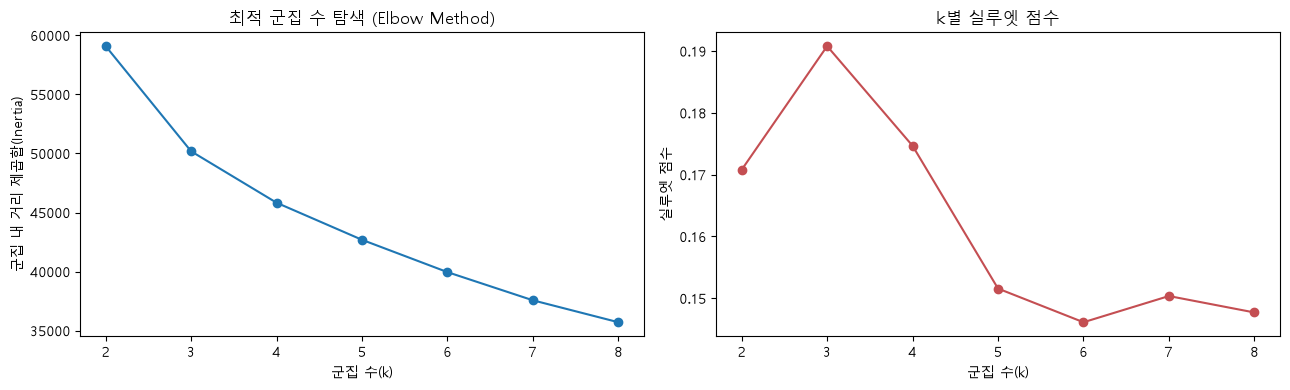

k=2: 실루엣 점수 0.171
k=3: 실루엣 점수 0.191
k=4: 실루엣 점수 0.175
k=5: 실루엣 점수 0.152
k=6: 실루엣 점수 0.146
k=7: 실루엣 점수 0.150
k=8: 실루엣 점수 0.148


In [5]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 9)

# 실루엣 스코어는 전체 데이터로 계산하면 느려서 일부만 샘플링해서 평가
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("군집 수(k)")
axes[0].set_ylabel("군집 내 거리 제곱합(Inertia)")
axes[0].set_title("최적 군집 수 탐색 (Elbow Method)")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#C44E52")
axes[1].set_xlabel("군집 수(k)")
axes[1].set_ylabel("실루엣 점수")
axes[1].set_title("k별 실루엣 점수")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: 실루엣 점수 {s:.3f}")

### K-means 학습 (k=3)

실루엣 스코어 가장 큰 k=3로 확정  
(유형별로 쪼개기위해 변경 고려 )

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    3932
1    1293
2    4902
Name: count, dtype: int64

### 군집별 특성 프로파일링

각 군집의 변수별 평균값을 확인해서 군집마다 어떤 성격을 갖는지 파악

In [7]:
cluster_profile = df.groupby("Cluster")[cluster_cols].mean().round(2)
cluster_profile

,Total_Trans_Amt,Total_Amt_Chng_Q4_Q1,Avg_Utilization_Ratio,Total_Revolving_Bal,Contacts_Count_12_mon,Total_Relationship_Count,Customer_Age
Cluster,,,,,,,
0,3309.25,0.72,0.05,400.43,2.64,3.93,46.48
1,11834.83,0.78,0.18,1408.41,2.16,2.07,45.48
2,3322.27,0.78,0.48,1709.56,2.39,4.18,46.43
